<a href="https://colab.research.google.com/github/MYTHRIGOUD123/Datapreprocessing/blob/main/studentperformance0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df =pd.read_csv('/content/student_performance_updated_1000.csv')
print(df)
print(df.describe())
filtered = df[df['StudentID']>50]
print("filtered data")
print(filtered)
print(df.isnull().sum())
mean_attendance = df['AttendanceRate'].mean()
df['AttendanceRate'] = df['AttendanceRate'].fillna(mean_attendance)
#df['AttendanceRate'].fillna(df['AttendanceRate'].mean(),inplace = True)
print("After filling data with mean")
print(df)
columns_to_fill = ['Study Hours','FinalGrade','Attendance (%)']

for col in columns_to_fill:
  mean_value = df[col].mean()
  df[col] = df[col].fillna(mean_value)
  print("AFTER FILLING THE STUDY HOURS , FINALGRADE AND ATTENDANCE PERCENT")
  print(df)
  print(df.isnull().sum())
num_columns_to_fill = [
    "StudentID",
    "StudyHoursPerWeek",
    "PreviousGrade",
    "Online Classes Taken",
]

for col in num_columns_to_fill:
    if col in df.columns:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

cat_columns_to_fill = [
    "Gender",
    "ExtracurricularActivities",
    "ParentalSupport",
]

for col in cat_columns_to_fill:
    if col in df.columns:
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)

if "Name" in df.columns:
    df["Name"] = df["Name"].fillna("Unknown Student")

print("FINAL MISSING VALUES")
print(df.isnull().sum())

     StudentID            Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0          1.0            John    Male            85.0               15.0   
1          2.0           Sarah  Female            90.0               20.0   
2          3.0            Alex    Male            78.0               10.0   
3          4.0         Michael    Male            92.0               25.0   
4          5.0            Emma  Female             NaN               18.0   
..         ...             ...     ...             ...                ...   
995        NaN  Kenneth Murray    Male            85.0               20.0   
996     4497.0       Amy Stout  Female            91.0                NaN   
997     1886.0             NaN    Male            85.0                8.0   
998     7636.0  Joseph Sherman    Male            88.0               17.0   
999     8021.0     Maria Walls  Female            88.0               10.0   

     PreviousGrade  ExtracurricularActivities ParentalSupport  FinalGrade  

 AUTOMATED STUDENT PERFORMANCE REPORT 
Total Records Analyzed: 1000
Total Data Features : 12

----------------------------------------
Key Performance Metrics (Averages):
----------------------------------------
• Academic Final Grade: 80.03
• Study Hours Per Week : 17.65 hrs
• Attendance Rate : 85.51%

----------------------------------------
Gender-Based Performance Breakdown:
----------------------------------------
• Female: 451.0 students | Avg Final Grade: 80.46
• Male: 549.0 students | Avg Final Grade: 79.68

----------------------------------------
Parental Support Level vs. Final Grade:
----------------------------------------
• Medium Support: Avg Grade of 80.43
• Low Support: Avg Grade of 80.31
• High Support: Avg Grade of 79.44



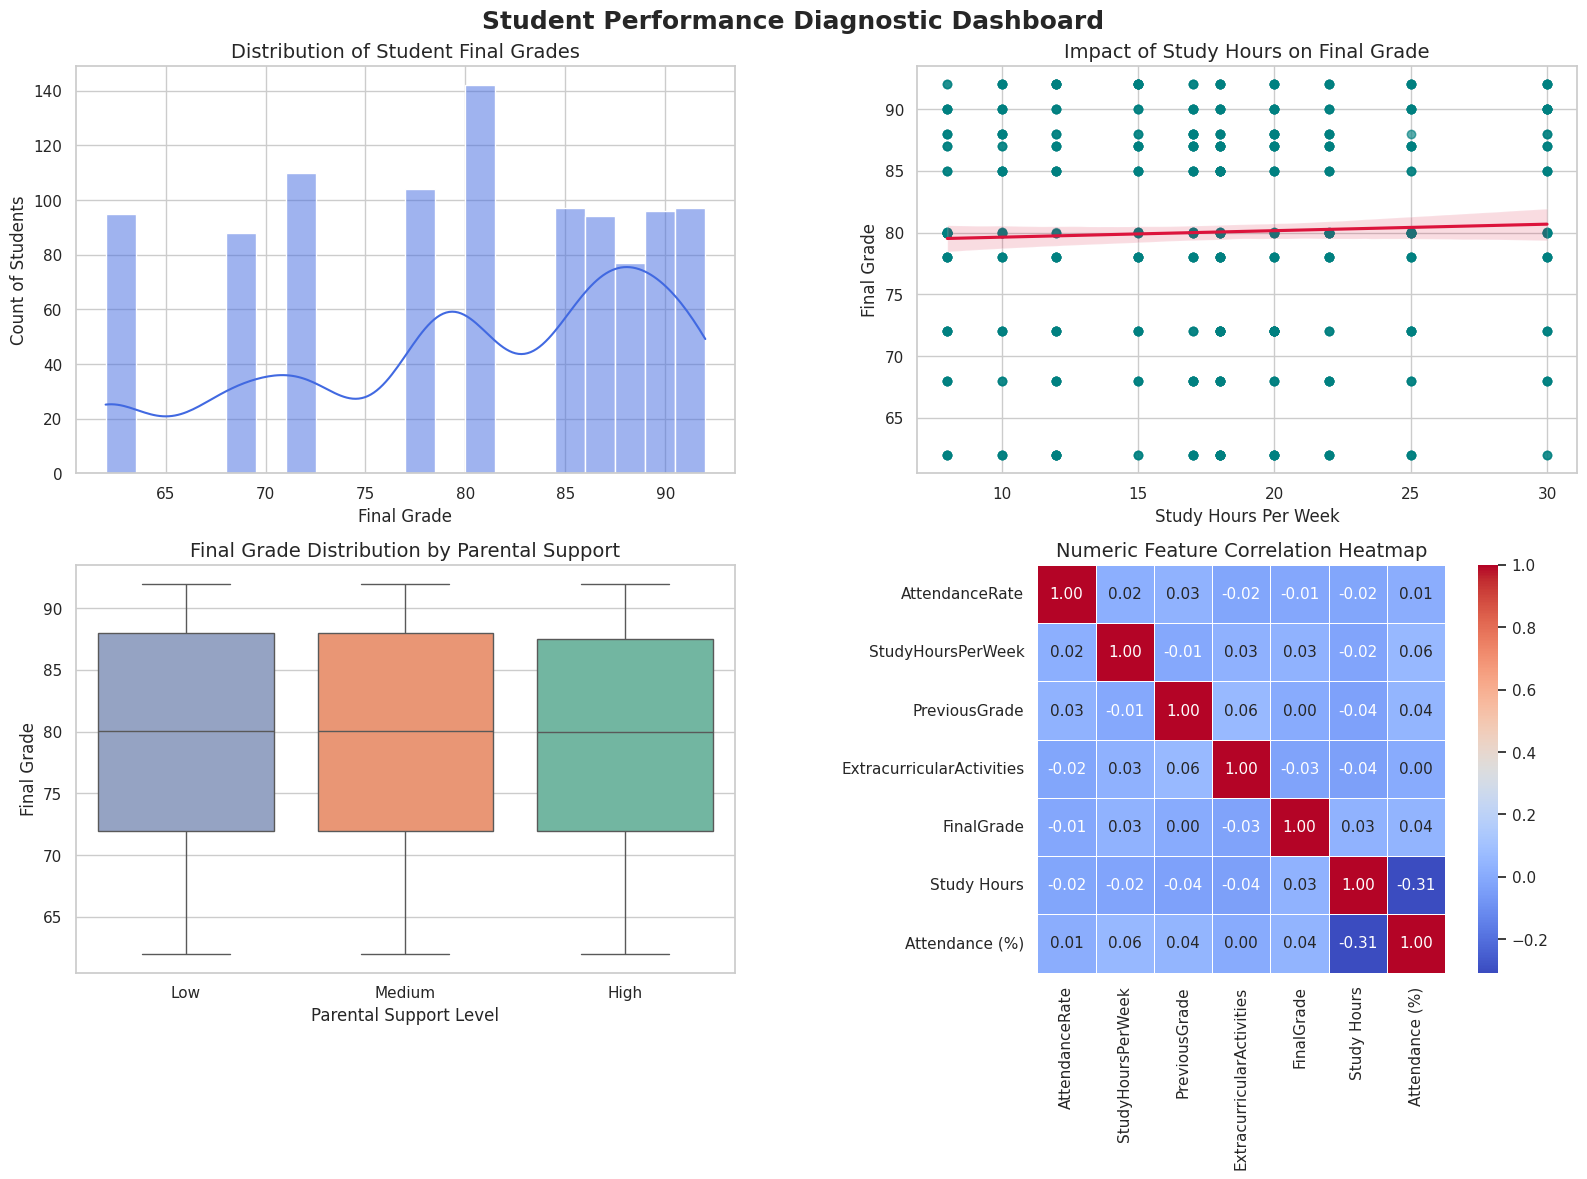

In [17]:

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

print("="*60)
print(" AUTOMATED STUDENT PERFORMANCE REPORT ")
print("="*60)

print(f"Total Records Analyzed: {df.shape[0]}")
print(f"Total Data Features : {df.shape[1]}\n")

print("-" * 40)
print("Key Performance Metrics (Averages):")
print("-" * 40)
print(f"• Academic Final Grade: {df['FinalGrade'].mean():.2f}")
print(f"• Study Hours Per Week : {df['StudyHoursPerWeek'].mean():.2f} hrs")
print(f"• Attendance Rate : {df['AttendanceRate'].mean():.2f}%")

print("\n" + "-" * 40)
print("Gender-Based Performance Breakdown:")
print("-" * 40)
gender_summary = df.groupby('Gender')['FinalGrade'].agg(['count', 'mean']).round(2)
for gender, row in gender_summary.iterrows():
    print(f"• {gender}: {row['count']} students | Avg Final Grade: {row['mean']}")

print("\n" + "-" * 40)
print("Parental Support Level vs. Final Grade:")
print("-" * 40)
parent_summary = df.groupby('ParentalSupport')['FinalGrade'].mean().sort_values(ascending=False).round(2)
for support_lvl, grade in parent_summary.items():
    print(f"• {support_lvl} Support: Avg Grade of {grade}")
print("="*60 + "\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Student Performance Diagnostic Dashboard', fontsize=18, fontweight='bold', y=0.98)

sns.histplot(df['FinalGrade'], kde=True, color='royalblue', bins=20, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Student Final Grades')
axes[0, 0].set_xlabel('Final Grade')
axes[0, 0].set_ylabel('Count of Students')

sns.regplot(data=df, x='StudyHoursPerWeek', y='FinalGrade',
            scatter_kws={'alpha':0.4, 'color': 'teal'}, line_kws={'color': 'crimson'}, ax=axes[0, 1])
axes[0, 1].set_title('Impact of Study Hours on Final Grade')
axes[0, 1].set_xlabel('Study Hours Per Week')
axes[0, 1].set_ylabel('Final Grade')

support_order = [x for x in ['Low', 'Medium', 'High'] if x in df['ParentalSupport'].unique()]
if not support_order:
    support_order = df['ParentalSupport'].value_counts().index

sns.boxplot(data=df, x='ParentalSupport', y='FinalGrade', order=support_order,hue='ParentalSupport', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Final Grade Distribution by Parental Support')
axes[1, 0].set_xlabel('Parental Support Level')
axes[1, 0].set_ylabel('Final Grade')

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col_to_remove in ['StudentID', 'Student_ID', 'ID']:
    if col_to_remove in numeric_cols:
        numeric_cols.remove(col_to_remove)

corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True, ax=axes[1, 1])
axes[1, 1].set_title('Numeric Feature Correlation Heatmap')

plt.tight_layout()
plt.show()
